## Теоретическая часть: 20 вопросов

### Вставьте пропущенные термины, обозначения в ячейки ниже.

1. Дисперсия характеризует **рассеяние** данных относительно среднего значения.

2. Для интервального ряда строится **гистограмма**, чтобы отобразить распределение частот.

3. Квартили делят данные на **четыре** части.

4. Медиана — это значение, которое **делит** выборку на две равные части.

5. Корреляция измеряет степень **зависимости** между двумя переменными.

6. Функция Лапласа используется для вычисления **накопленных** вероятностей в нормальном распределении.

7. Распределение Хи-квадрат применяется для проверки гипотез о **нормальном** распределении.

8. Гамма-функция обобщает **факториал** на вещественные значения.

9. Основные типы ошибок в проверке гипотез — это ошибки **первого** и **второго** рода.

10. Критическая область определяется уровнем **значимости** и используется для проверки гипотез.

11. Критерий согласия Пирсона проверяет гипотезу о **нормальном** распределения данных.

12. MSE минимизирует **сумму** квадратов отклонений предсказаний от истинных значений.

13. MAE более устойчив к **выбросам** в данных.

14. Правило 3 сигм предполагает, что данные нормального распределения лежат в пределах **трех стандартных отклонений** от среднего значения.

15. Ядерные оценки плотности используются для **оценки плотности** распределения данных.

16. Гауссово и Экспоненциальное ядра являются примерами **ядерных функций** для KDE.

17. Оптимальный размер ядра в KDE определяет степень **интенсивности** сглаживания данных.

18. Линейная регрессия минимизирует **квадратичную** функцию потерь для нахождения коэффициентов.

19. Выбросы можно определить с использованием **квартилей** и межквартильного размаха.

20. RANSAC используется для построения моделей в условиях наличия **выбросов**.

## Практическая часть: 6 задач

### Задача 1: Интервальный ряд и основные статистики

Создайте интервальный ряд из данных `iqs.csv`. Количество интервалов подберите с помощью формулы Старджесса. Вычислите среднее, моду, медиану и визуализируйте гистограмму распределения.

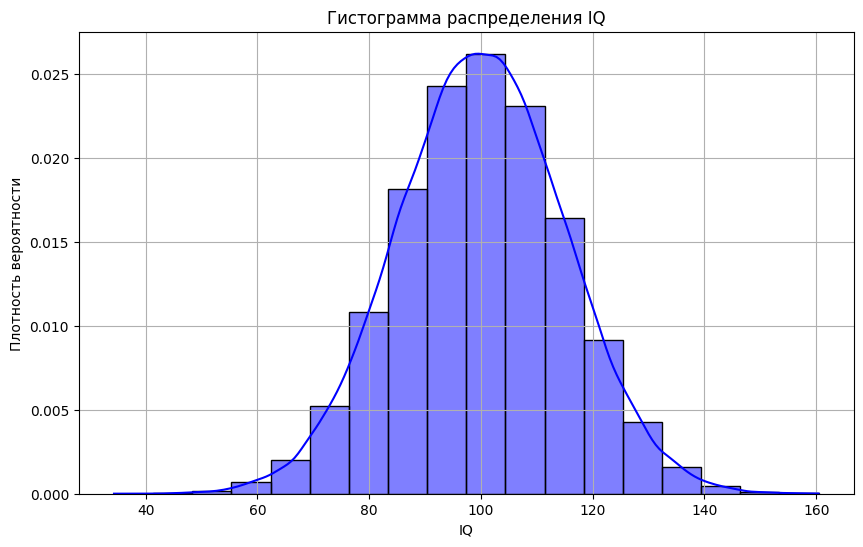

Среднее значение IQ: 100.01
Мода IQ: 98.06
Медиана IQ: 100.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('iqs.csv')
iq_data = data['IQ']

# расчет количества интервалов по формуле Старджесса
n = len(iq_data)
k = int(np.ceil(1 + 3.322 * np.log10(n)))  # формула Старджесса

# создание интервального ряда
# нахожу минимальное и максимальное значение данных
min_val = iq_data.min()
max_val = iq_data.max()

# строю интервалы
intervals = np.linspace(min_val, max_val, k + 1)

# построение гистограммы
plt.figure(figsize=(10, 6))
sns.histplot(iq_data, bins=intervals, kde=True, color='blue', stat='density', edgecolor='black')
plt.title('Гистограмма распределения IQ')
plt.xlabel('IQ')
plt.ylabel('Плотность вероятности')
plt.grid(True)
plt.show()

# среднее
mean_iq = iq_data.mean()
print(f"Среднее значение IQ: {mean_iq:.2f}")

# мода
mode_iq = iq_data.mode()[0]
print(f"Мода IQ: {mode_iq:.2f}")

# медиана
median_iq = iq_data.median()
print(f"Медиана IQ: {median_iq:.2f}")


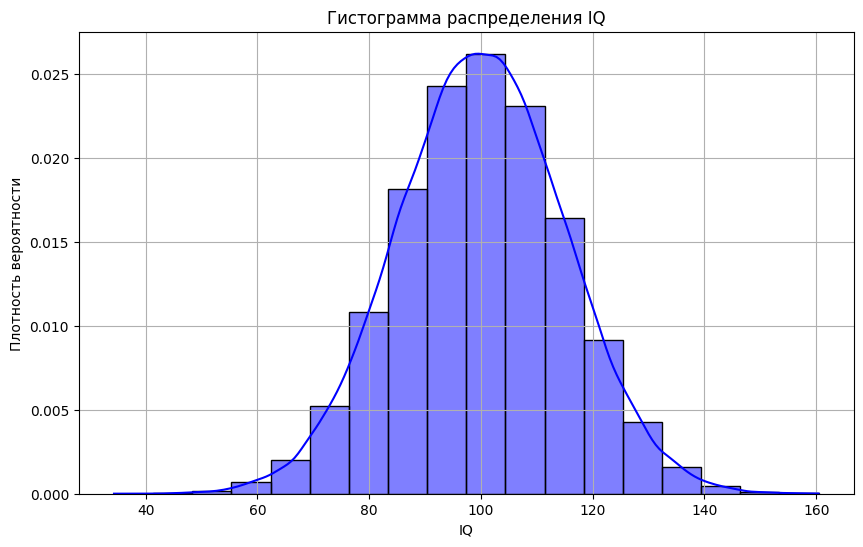

Среднее значение IQ (по интервальным данным): 100.02
Мода IQ: интервал [97.37, 104.374) с частотой 18368
Медиана IQ: 116.44


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('iqs.csv')
iq_data = data['IQ']

# расчет количества интервалов по формуле Старджесса
n = len(iq_data)
k = int(np.ceil(1 + 3.322 * np.log10(n)))  # формула Старджесса

# создание интервального ряда
min_val = iq_data.min()
max_val = iq_data.max()

# строю интервалы
intervals = np.linspace(min_val, max_val, k + 1)

# распределение по интервалам
iq_data_binned = pd.cut(iq_data, bins=intervals, right=False)

# частота в каждом интервале
freq = iq_data_binned.value_counts().sort_index()

# создание таблицы с данными
data_table = pd.DataFrame({
    'Interval': freq.index,
    'Frequency': freq.values
})

# расчет среднего значения для интервальных данных
midpoints = [(interval.left + interval.right) / 2 for interval in data_table['Interval']]
weighted_mean = np.sum(midpoints * data_table['Frequency']) / np.sum(data_table['Frequency'])

# построение гистограммы
plt.figure(figsize=(10, 6))
sns.histplot(iq_data, bins=intervals, kde=True, color='blue', stat='density', edgecolor='black')
plt.title('Гистограмма распределения IQ')
plt.xlabel('IQ')
plt.ylabel('Плотность вероятности')
plt.grid(True)
plt.show()

# вывод статистик
print(f"Среднее значение IQ (по интервальным данным): {weighted_mean:.2f}")

# мода (интервал с максимальной частотой)
mode_interval = data_table.loc[data_table['Frequency'].idxmax()]
print(f"Мода IQ: интервал {mode_interval['Interval']} с частотой {mode_interval['Frequency']}")

# медиана: находим интервал с медианой
cum_freq = np.cumsum(data_table['Frequency'])
median_interval = data_table[cum_freq >= n / 2].iloc[0]

# вычисляем медиану внутри интервала
lower_bound = median_interval['Interval'].left
interval_width = median_interval['Interval'].right - median_interval['Interval'].left
cumulative_freq_before = cum_freq[data_table['Interval'] == median_interval['Interval'].left].iloc[0] if cum_freq[data_table['Interval'] == median_interval['Interval'].left].size > 0 else 0
median = lower_bound + (n / 2 - cumulative_freq_before) / median_interval['Frequency'] * interval_width

print(f"Медиана IQ: {median:.2f}")


### Задача 2: Проверка гипотезы о среднем

Используя данные `developers.csv`, проверьте гипотезу \( H_0: \mu = 300000 \) для зарплат разработчиков.

Используйте критерий Стьюдента с уровнем значимости \( \alpha = 0.05 \).

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

data = pd.read_csv('developers.csv')
salaries = data['Salary']

# проверка гипотезы с использованием t-критерия
mu_0 = 300000  # гипотетическое среднее
alpha = 0.05  # уровень значимости

# рассчитываю выборочное среднее, стандартное отклонение и размер выборки
sample_mean = np.mean(salaries)
sample_std = np.std(salaries, ddof=1)  # использую ddof=1 для исправленного стандартного отклонения
n = len(salaries)

# статистика t
t_statistic = (sample_mean - mu_0) / (sample_std / np.sqrt(n))

# степени свободы
df = n - 1

# двусторонний тест, так как гипотеза H1: mu != 300000
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

# вывод результатов
print(f"Статистика t: {t_statistic:.4f}")
print(f"p-значение: {p_value:.4f}")

# проверка гипотезы
if p_value < alpha:
    print("Отвергаем нулевую гипотезу. Средняя зарплата отличается от 300000")
else:
    print("Не отвергаем нулевую гипотезу. Средняя зарплата не отличается от 300000")


Статистика t: -1.3432
p-значение: 0.1792
Не отвергаем нулевую гипотезу. Средняя зарплата не отличается от 300000


### Задача 3: Линейная регрессия и метрики качества

На основе данных `developers.csv` постройте линейную регрессию, предсказывающую вклад.

Вычислите MSE, MAE и R², визуализируйте данные и модель.

MSE (Среднеквадратичная ошибка): 2496577022.71
MAE (Средняя абсолютная ошибка): 39830.42
R² (Коэффициент детерминации): 0.67


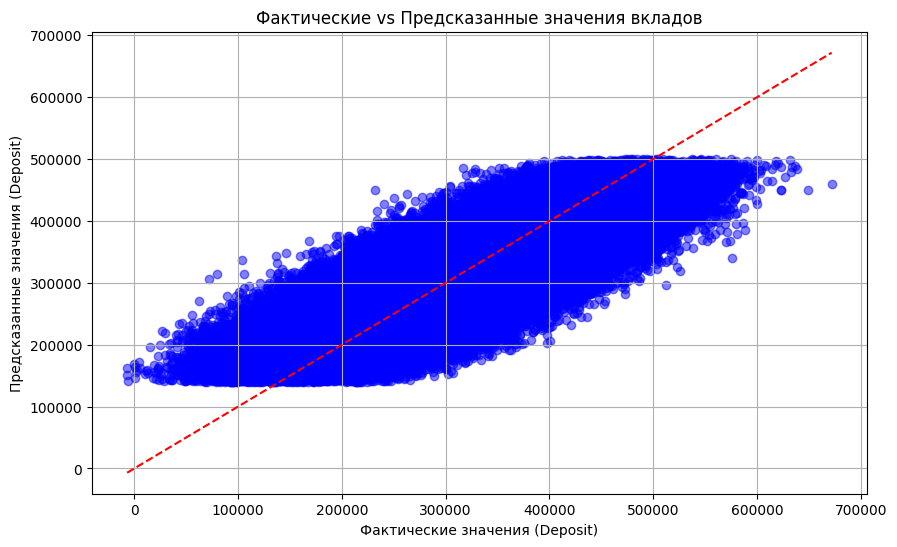

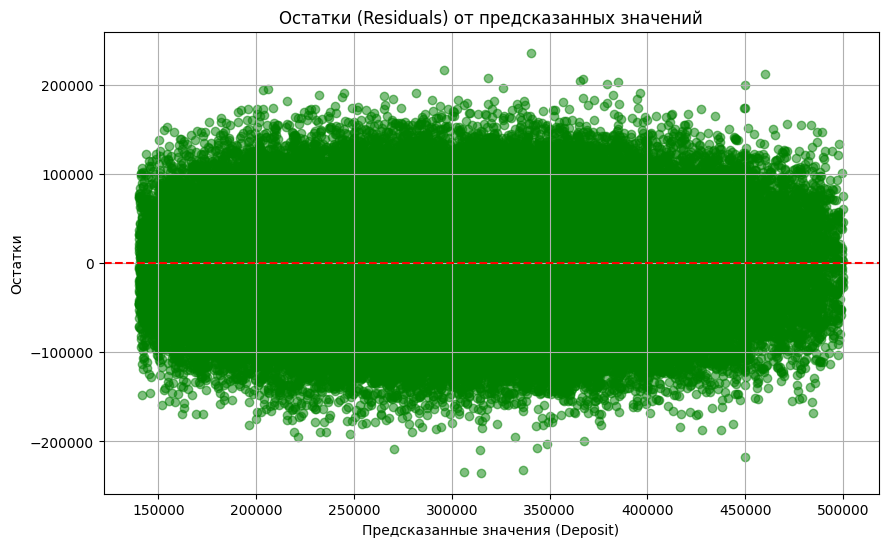

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('developers.csv')

# определяю независимые переменные и зависимую переменную
X = data[['Salary', 'Experience', 'Education']]  # независимые переменные
y = data['Deposit']  # зависимая переменная

# разделяю данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# строю модель линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# предсказания модели на тестовых данных
y_pred = model.predict(X_test)

# вычисляю метрики
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE (Среднеквадратичная ошибка): {mse:.2f}')
print(f'MAE (Средняя абсолютная ошибка): {mae:.2f}')
print(f'R² (Коэффициент детерминации): {r2:.2f}')

# визуализация данных и модели:
# график фактических значений против предсказанных
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Фактические vs Предсказанные значения вкладов')
plt.xlabel('Фактические значения (Deposit)')
plt.ylabel('Предсказанные значения (Deposit)')
plt.grid(True)
plt.show()

# график зависимости остаточных ошибок от предсказанных значений
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='green', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки (Residuals) от предсказанных значений')
plt.xlabel('Предсказанные значения (Deposit)')
plt.ylabel('Остатки')
plt.grid(True)
plt.show()


### Задача 4: Методы борьбы с выбросами

Используя данные `AirPassengers.csv`, удалите выбросы по правилу 3 сигм. Визуализируйте данные до и после удаления.

        Month  #Passengers
0  1949-01-01          232
1  1949-02-01          247
2  1949-03-01          246
3  1949-04-01          228
4  1949-05-01          229


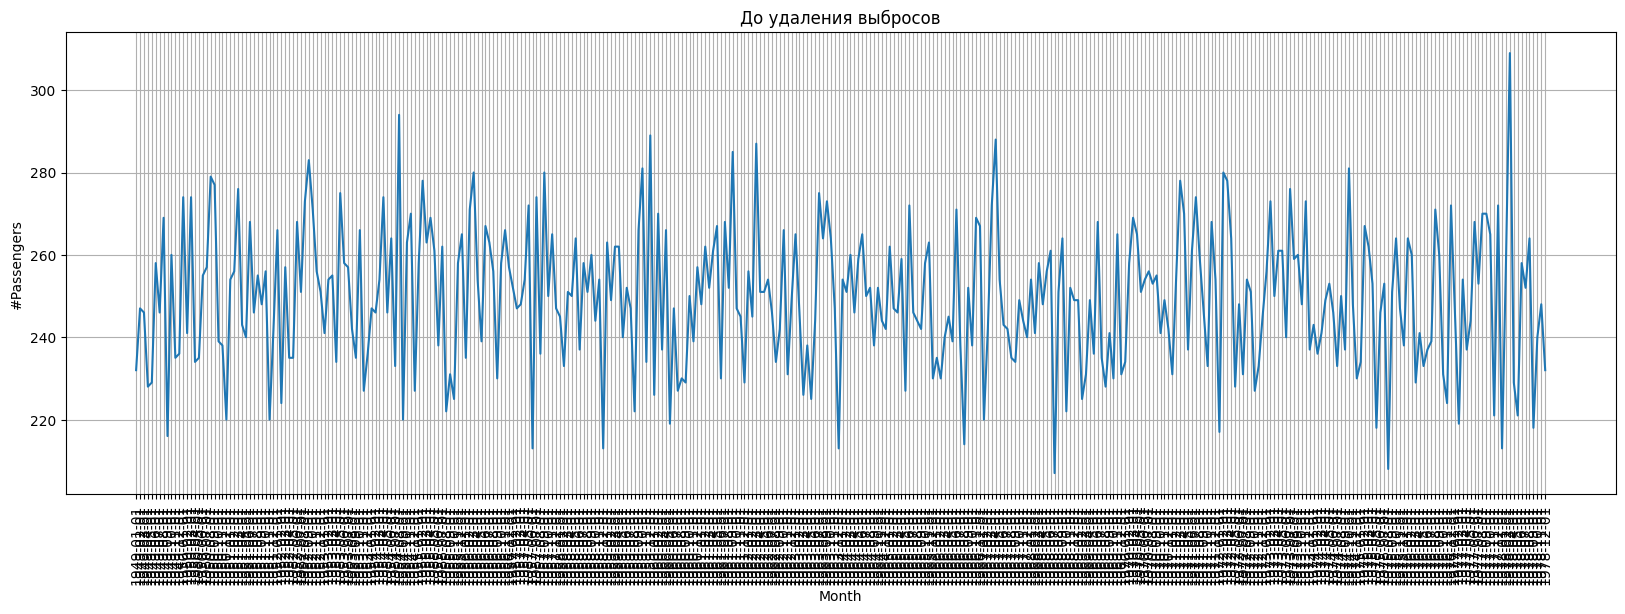

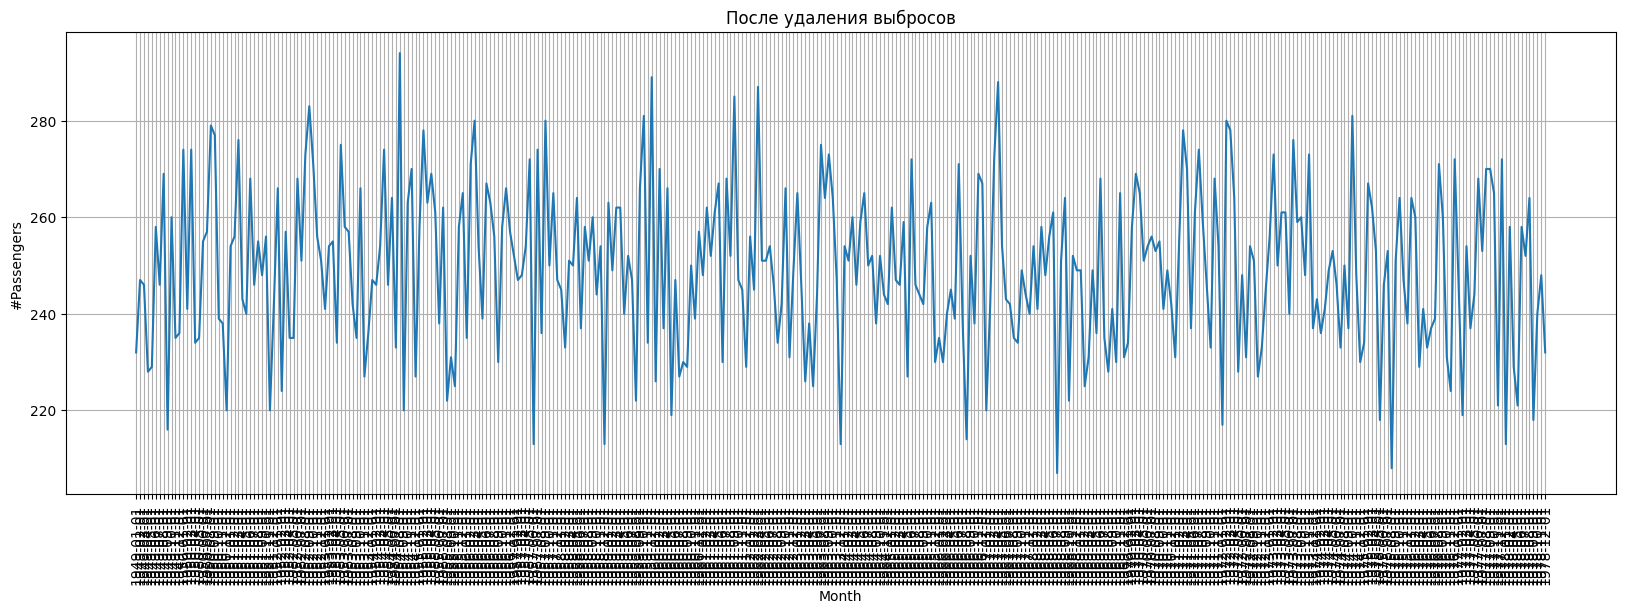

Исходный размер данных: 360
Размер данных после удаления выбросов: 359
Удалено выбросов: 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('AirPassengers.csv')

# проверяю первые строки данных
print(data.head())

# определяю выбросы по правилу 3 сигм
mean = data['#Passengers'].mean()
std_dev = data['#Passengers'].std()

# рассчитываю верхний и нижний пределы по правилу 3 сигм
upper_limit = mean + 3 * std_dev
lower_limit = mean - 3 * std_dev

# удаляю выбросы, оставив только те значения, которые находятся в пределах 3 сигм
data_cleaned = data[(data['#Passengers'] >= lower_limit) & (data['#Passengers'] <= upper_limit)]

# график до удаления выбросов
plt.figure(figsize=(20, 6))
sns.lineplot(x='Month', y='#Passengers', data=data)
plt.title('До удаления выбросов')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# график после удаления выбросов
plt.figure(figsize=(20, 6))
sns.lineplot(x='Month', y='#Passengers', data=data_cleaned)
plt.title('После удаления выбросов')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# вывод информации о выбросах
print(f'Исходный размер данных: {data.shape[0]}')
print(f'Размер данных после удаления выбросов: {data_cleaned.shape[0]}')
print(f'Удалено выбросов: {data.shape[0] - data_cleaned.shape[0]}')


### Задача 5: Ядерные оценки плотности (KDE)

Постройте KDE для данных `iqs.csv` с использованием Гауссового ядра. Сравните результаты для разных ширин ядра (0.5, 1.0, 2.0).

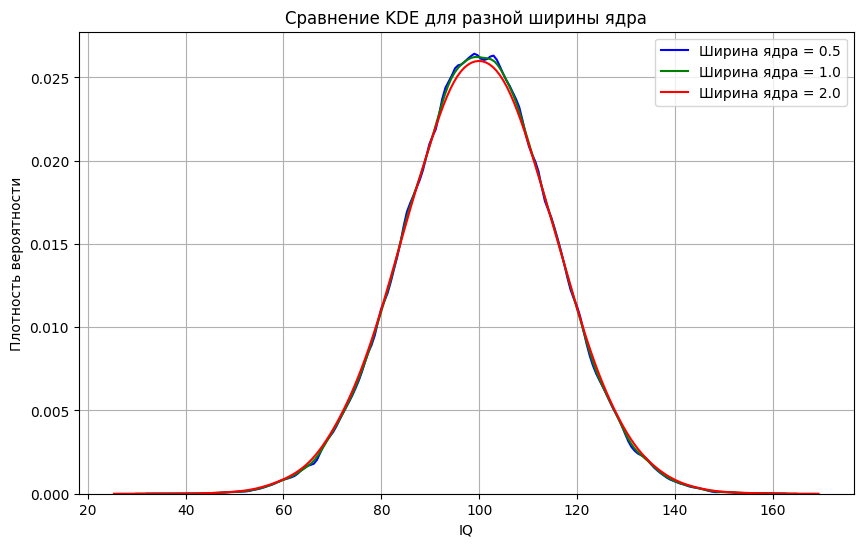

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('iqs.csv')

# строю KDE для разной ширины ядра
plt.figure(figsize=(10, 6))

# KDE с шириной ядра 0.5
sns.kdeplot(data['IQ'], bw_adjust=0.5, label='Ширина ядра = 0.5', color='blue')

# KDE с шириной ядра 1.0
sns.kdeplot(data['IQ'], bw_adjust=1.0, label='Ширина ядра = 1.0', color='green')

# KDE с шириной ядра 2.0
sns.kdeplot(data['IQ'], bw_adjust=2.0, label='Ширина ядра = 2.0', color='red')

# график
plt.title('Сравнение KDE для разной ширины ядра')
plt.xlabel('IQ')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()


### Задача 6: Гамма-функция и распределение

Реализуйте гамма-функцию с помощью `scipy.special` и визуализируйте её значения для аргументов от 0 до 5.

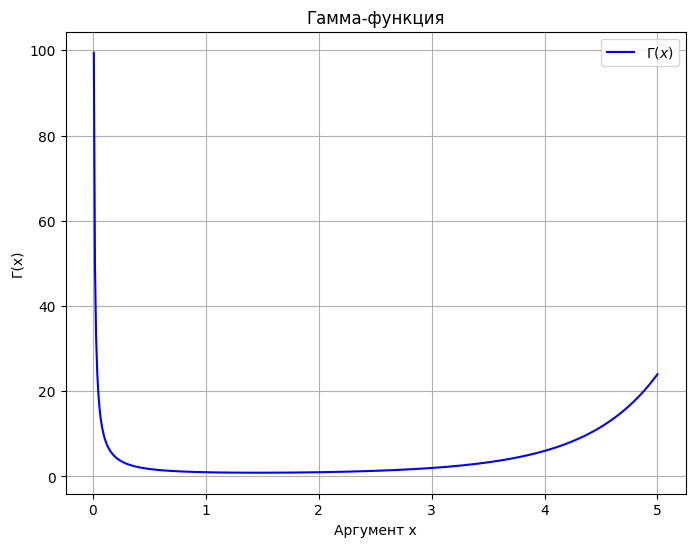

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# создаю массив аргументов от 0 до 5
x = np.linspace(0.01, 5, 500)  # 0.01 вместо 0, чтобы избежать деления на ноль

# вычисляю значения гамма-функции для этих аргументов
y = gamma(x)

# график
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$\Gamma(x)$', color='b')
plt.title('Гамма-функция')
plt.xlabel('Аргумент x')
plt.ylabel('Г(x)')
plt.grid(True)
plt.legend()
plt.show()
